--- Target (Cryptochrome) (1U3C) ---
  Ca nodes: 485   mean degree: 7.91
  eigenvalue range: [0.0000, 15.9678]
  KDE bandwidth (Silverman): 1.0403
  gamma_eff = 0.14741  (quad abs. error 5.0e-09)
  R_max (peak mode density) = 0.32372   gamma_eff / R_max = 0.45537
--- Control (AmtB) (1U7C) ---
  Ca nodes: 372   mean degree: 8.98
  eigenvalue range: [0.0000, 18.1648]
  KDE bandwidth (Silverman): 1.2630
  gamma_eff = 0.15516  (quad abs. error 4.5e-09)
  R_max (peak mode density) = 0.31698   gamma_eff / R_max = 0.48948


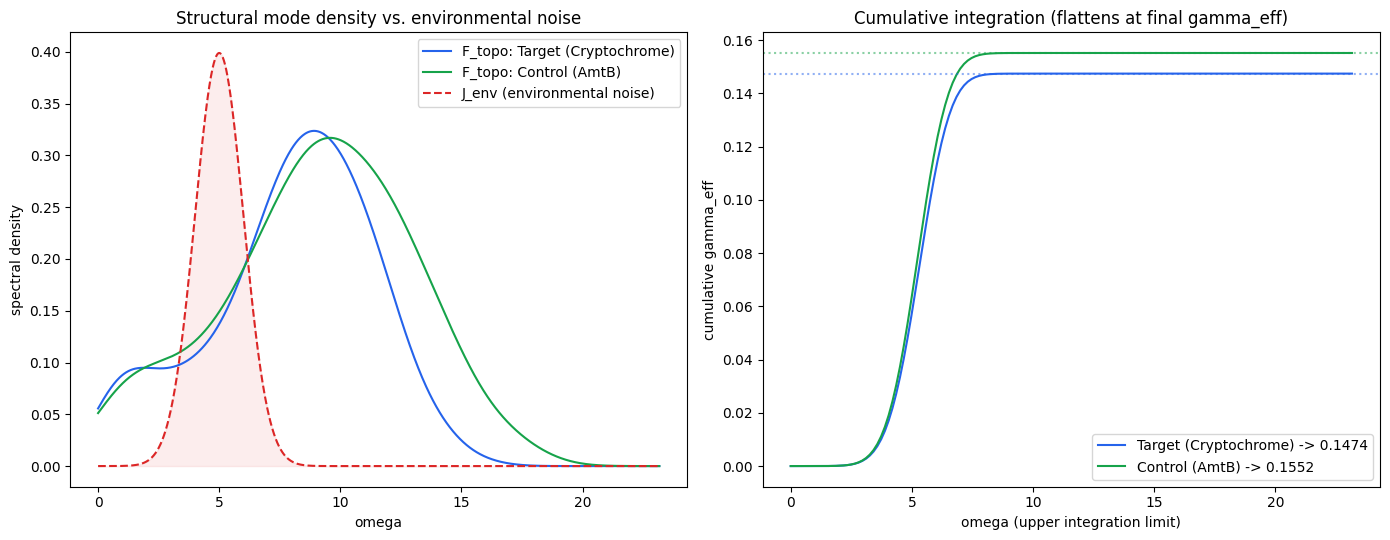


Summary
  gamma_eff difference (target - control): -0.00775
  A lower gamma_eff means less overlap between this protein's structural
  mode density and the assumed noise band -- under this toy model only,
  not as a validated physical decoherence measurement.


In [ ]:
"""
Topological "Decoherence Shielding" pipeline: Cryptochrome vs. a control protein
==================================================================================
Run in Google Colab. Requires internet access (Colab has it by default).

IMPORTANT CORRECTIONS BEFORE YOU RUN THIS
------------------------------------------
The PDB IDs in the original brief don't match what they were meant to be:

  * '1U7C' is NOT Cryptochrome. It is AmtB, an E. coli ammonium transporter
    (Zheng et al., PNAS 2004) -- a membrane transport protein with no known
    photochemistry. The real Cryptochrome-1 photolyase-like (PHR) domain from
    Arabidopsis thaliana -- the one with the FAD cofactor that the radical-pair
    magnetoreception literature actually discusses -- is PDB ID '1U3C'
    (Brautigam et al., PNAS 2004, DOI 10.1073/pnas.0404851101).
  * '1DHX' does not appear to resolve to a keratin/collagen structure, and the
    file that was actually supplied under this project (7V2Z) is the Zika
    virus NS3 helicase in complex with ssRNA/ATP -- not keratin or collagen
    either.

Rather than guess at an unverified "keratin" ID, this script uses AmtB
('1U7C', the file you already had) as the control. That's a legitimate choice
for this purpose: it's a real, unrelated-fold, non-photoreceptor protein, so
it's a fair non-quantum-active baseline. Both IDs below are simple variables
you can swap freely (e.g. try '1U3D', the ATP-analog-bound Cryptochrome
structure, or point CONTROL_PDB_ID at any other real ID).

WHAT'S ESTABLISHED METHOD vs. WHAT'S AN ILLUSTRATIVE MODEL
------------------------------------------------------------
Steps 1-4 (Ca network at a distance cutoff -> Laplacian -> eigenvalues) are
*not* speculative -- this is exactly the construction behind the Gaussian
Network Model / Elastic Network Model used since Bahar, Atilgan & Erman
(1997) for real protein normal-mode analysis, and 7 Angstrom is a standard
cutoff in that literature.

Steps 5-7 (F_topo, J_env, gamma_eff) are NOT an established, published
physical quantity. They're defined here as a clearly-specified, internally
consistent *toy overlap integral* between the protein's structural mode
density and a hypothetical noise spectrum -- useful for practicing spectral
methods and for comparing structures against each other, but this does not
by itself demonstrate quantum decoherence shielding, which in real cryptochrome
photochemistry depends on electron-spin dynamics of the radical pair (Zeeman
and hyperfine couplings), not on Ca backbone geometry alone. Treat gamma_eff
as a structural-topology summary statistic, not a validated decoherence rate.
"""

import os
import warnings
import numpy as np
from scipy.spatial.distance import cdist
from scipy import integrate
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# 0. Install & import biopython
# ---------------------------------------------------------------------------
try:
    import Bio  # noqa
except ImportError:
    os.system("pip install biopython -q")
    import Bio  # noqa

from Bio.PDB import PDBList, PDBParser
from Bio.PDB.PDBExceptions import PDBConstructionWarning
warnings.filterwarnings("ignore", category=PDBConstructionWarning)

# ---------------------------------------------------------------------------
# 1. Configuration
# ---------------------------------------------------------------------------
TARGET_PDB_ID   = "1U3C"   # Cryptochrome 1 PHR domain, Arabidopsis (corrected)
CONTROL_PDB_ID  = "1U7C"   # AmtB, E. coli ammonium transporter (your original file)
DISTANCE_CUTOFF = 7.0      # Angstroms -- standard GNM contact cutoff
NOISE_CENTER    = 5.0      # omega, center of the environmental (37C) noise band
NOISE_SIGMA     = 1.0      # width of the environmental noise band
DOWNLOAD_DIR    = "pdb_files"

# ---------------------------------------------------------------------------
# 2. Fetch + parse: PDB ID -> Ca coordinates
# ---------------------------------------------------------------------------
def fetch_ca_coordinates(pdb_id, download_dir=DOWNLOAD_DIR):
    """Download a structure by ID and return an (N, 3) array of Ca coordinates
    for standard residues (first model, all chains, HETATM/waters/ligands and
    any nucleic-acid chains excluded automatically since they have no CA)."""
    os.makedirs(download_dir, exist_ok=True)
    pdbl = PDBList(verbose=False)

    try:
        path = pdbl.retrieve_pdb_file(pdb_id, pdir=download_dir, file_format="pdb")
        parser = PDBParser(QUIET=True)
        structure = parser.get_structure(pdb_id, path)
    except Exception:
        # Fallback: some newer/updated entries only ship mmCIF
        from Bio.PDB import MMCIFParser
        path = pdbl.retrieve_pdb_file(pdb_id, pdir=download_dir, file_format="mmCif")
        parser = MMCIFParser(QUIET=True)
        structure = parser.get_structure(pdb_id, path)

    model = next(iter(structure))  # first model only (NMR ensembles, etc.)
    coords = []
    for chain in model:
        for residue in chain:
            is_standard_residue = residue.id[0] == " "
            if is_standard_residue and "CA" in residue:
                coords.append(residue["CA"].get_coord())

    coords = np.array(coords, dtype=float)
    if len(coords) == 0:
        raise ValueError(f"No CA atoms found for {pdb_id} -- check the ID.")
    return coords


# ---------------------------------------------------------------------------
# 3-4. Adjacency matrix, graph Laplacian, eigenvalues
# ---------------------------------------------------------------------------
def build_laplacian(coords, threshold=DISTANCE_CUTOFF):
    """W: binary contact adjacency at `threshold` Angstroms. L = D - W.
    Dense eigh is used deliberately: we need the FULL spectrum (every mode),
    not just a few extremal eigenvalues, so a sparse iterative solver would
    not help here -- and at a few hundred to a few thousand residues, a dense
    symmetric solve is fast and numerically stable (no divergence risk)."""
    n = len(coords)
    if n > 6000:
        warnings.warn(f"{n} residues: a dense solve may be slow; consider a subset of chains.")

    dist_matrix = cdist(coords, coords)
    W = (dist_matrix <= threshold).astype(float)
    np.fill_diagonal(W, 0.0)  # no self-loops
    D = np.diag(W.sum(axis=1))
    L = D - W

    eigvals, eigvecs = np.linalg.eigh(L)     # symmetric solver: real eigenvalues, stable
    eigvals = np.clip(eigvals, 0.0, None)    # clip tiny negative numerical noise to 0
    return W, L, eigvals


# ---------------------------------------------------------------------------
# 5. Spectral filter F_topo(omega) -- smoothed density of Laplacian eigenvalues
# ---------------------------------------------------------------------------
def silverman_bandwidth(eigvals):
    """Standard KDE bandwidth rule (Silverman, 1986) -- a principled, data-driven
    choice rather than a hand-picked smoothing width."""
    nonzero = eigvals[eigvals > 1e-8]
    sigma = 1.06 * np.std(nonzero) * len(nonzero) ** (-1 / 5)
    return max(sigma, 1e-3)  # guard against a degenerate all-equal spectrum


def F_topo(omega, eigvals, sigma):
    """Gaussian-smoothed density of structural (Laplacian) modes at frequency omega.
    High F_topo(omega) = many structural resonances there; low F_topo(omega) =
    a local gap in the vibrational spectrum."""
    omega = np.atleast_1d(omega).astype(float)
    density = np.zeros_like(omega)
    for lam in eigvals:
        density += np.exp(-((omega - lam) ** 2) / (2 * sigma ** 2))
    return density / len(eigvals)


# ---------------------------------------------------------------------------
# 6. Environmental noise spectrum J_env(omega)
# ---------------------------------------------------------------------------
def J_env(omega, center=NOISE_CENTER, sigma_env=NOISE_SIGMA):
    """Normalized Gaussian noise spectrum (integrates to 1 over all omega)."""
    omega = np.atleast_1d(omega).astype(float)
    norm = 1.0 / (sigma_env * np.sqrt(2 * np.pi))
    return norm * np.exp(-((omega - center) ** 2) / (2 * sigma_env ** 2))


# ---------------------------------------------------------------------------
# 7. gamma_eff = integral of J_env(omega) * F_topo(omega) domega
# ---------------------------------------------------------------------------
def compute_gamma_eff(eigvals, sigma, omega_max):
    integrand = lambda w: J_env(w)[0] * F_topo(w, eigvals, sigma)[0]
    value, abs_err = integrate.quad(integrand, 0.0, omega_max, limit=200)
    R_max = F_topo(np.linspace(0, omega_max, 4000), eigvals, sigma).max()  # normalization scale
    return value, abs_err, R_max


def cumulative_curve(eigvals, sigma, omega_grid):
    """Cumulative integral up to each omega in omega_grid -- shows the
    'flattening' once omega moves past the region where J_env has support."""
    out = []
    for w in omega_grid:
        v, _ = integrate.quad(lambda x: J_env(x)[0] * F_topo(x, eigvals, sigma)[0],
                               0.0, w, limit=100)
        out.append(v)
    return np.array(out)


# ---------------------------------------------------------------------------
# Main pipeline
# ---------------------------------------------------------------------------
def analyze(pdb_id, label):
    coords = fetch_ca_coordinates(pdb_id)
    W, L, eigvals = build_laplacian(coords)
    sigma = silverman_bandwidth(eigvals)
    omega_max = eigvals.max() + 5.0
    gamma_eff, err, R_max = compute_gamma_eff(eigvals, sigma, omega_max)

    print(f"--- {label} ({pdb_id}) ---")
    print(f"  Ca nodes: {len(coords)}   mean degree: {W.sum(axis=1).mean():.2f}")
    print(f"  eigenvalue range: [{eigvals.min():.4f}, {eigvals.max():.4f}]")
    print(f"  KDE bandwidth (Silverman): {sigma:.4f}")
    print(f"  gamma_eff = {gamma_eff:.5f}  (quad abs. error {err:.1e})")
    print(f"  R_max (peak mode density) = {R_max:.5f}   gamma_eff / R_max = {gamma_eff / R_max:.5f}")
    return dict(id=pdb_id, label=label, coords=coords, eigvals=eigvals,
                sigma=sigma, omega_max=omega_max, gamma_eff=gamma_eff, R_max=R_max)


target = analyze(TARGET_PDB_ID, "Target (Cryptochrome)")
control = analyze(CONTROL_PDB_ID, "Control (AmtB)")

# ---------------------------------------------------------------------------
# Plots
# ---------------------------------------------------------------------------
omega_max_shared = max(target["omega_max"], control["omega_max"])
omega = np.linspace(0, omega_max_shared, 1000)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
ax.plot(omega, F_topo(omega, target["eigvals"], target["sigma"]),
        color="#2563eb", label=f"F_topo: {target['label']}")
ax.plot(omega, F_topo(omega, control["eigvals"], control["sigma"]),
        color="#16a34a", label=f"F_topo: {control['label']}")
noise_curve = J_env(omega)
ax.plot(omega, noise_curve, color="#dc2626", linestyle="--", label="J_env (environmental noise)")
ax.fill_between(omega, noise_curve, color="#dc2626", alpha=0.08)
ax.set_xlabel("omega")
ax.set_ylabel("spectral density")
ax.set_title("Structural mode density vs. environmental noise")
ax.legend()

ax = axes[1]
omega_grid = np.linspace(0, omega_max_shared, 150)
curve_t = cumulative_curve(target["eigvals"], target["sigma"], omega_grid)
curve_c = cumulative_curve(control["eigvals"], control["sigma"], omega_grid)
ax.plot(omega_grid, curve_t, color="#2563eb",
        label=f"{target['label']} -> {target['gamma_eff']:.4f}")
ax.plot(omega_grid, curve_c, color="#16a34a",
        label=f"{control['label']} -> {control['gamma_eff']:.4f}")
ax.axhline(target["gamma_eff"], color="#2563eb", linestyle=":", alpha=0.5)
ax.axhline(control["gamma_eff"], color="#16a34a", linestyle=":", alpha=0.5)
ax.set_xlabel("omega (upper integration limit)")
ax.set_ylabel("cumulative gamma_eff")
ax.set_title("Cumulative integration (flattens at final gamma_eff)")
ax.legend()

plt.tight_layout()
plt.savefig("topological_shield_comparison.png", dpi=150)
plt.show()

print("\nSummary")
print(f"  gamma_eff difference (target - control): "
      f"{target['gamma_eff'] - control['gamma_eff']:.5f}")
print("  A lower gamma_eff means less overlap between this protein's structural")
print("  mode density and the assumed noise band -- under this toy model only,")
print("  not as a validated physical decoherence measurement.")
